# Home Credit Stability v4 — Data & Model Validation

Notebook này tập trung vào đúng 3 việc chính:

1. Validate data ở `silver.hc_v2_cleansed` và `gold.hc_features_v2`.
2. Validate contract giữa training scripts và artifacts `.pkl`.
3. Đánh giá model bằng metrics + biểu đồ.

Model risk hiện tại là `customer_lgbm_v4_stability` với 35 feature, không dùng `credit_score` tự khai báo, `rating_ordinal`, giới tính, số con hoặc số thành viên gia đình.

In [2]:
from __future__ import annotations

import importlib
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
warnings.filterwarnings("ignore", message="X does not have valid feature names")

import duckdb
import joblib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "machinelearning").exists():
    ROOT = ROOT.parent

ML_DIR = ROOT / "machinelearning"
BACKEND_DIR = ROOT / "backend"
for item in (ROOT, BACKEND_DIR):
    if str(item) not in sys.path:
        sys.path.insert(0, str(item))

# Reload modules so a long-running Jupyter kernel does not keep old v3 feature lists.
import machinelearning.ml.validate_data as data_validation
import machinelearning.ml.retrain_customer_model as risk_train
import machinelearning.ml.train_scorecard as score_train

data_validation = importlib.reload(data_validation)
risk_train = importlib.reload(risk_train)
score_train = importlib.reload(score_train)

REQUIRED_COLUMNS = data_validation.REQUIRED_COLUMNS
LGBM_FEATURES = risk_train.ALL_FEATURES
LGBM_NUMERIC_FEATURES = risk_train.NUMERIC_FEATURES
LGBM_CATEGORICAL_FEATURES = risk_train.CATEGORICAL_FEATURES
LGBM_QUERY = risk_train._QUERY
MODEL_VERSION = risk_train.MODEL_VERSION

SCORECARD_FEATURES = score_train.ALL_FEATURES
SCORECARD_NUMERIC_FEATURES = score_train.NUMERIC_FEATURES
SCORECARD_CATEGORICAL_FEATURES = score_train.CATEGORICAL_FEATURES
SCORECARD_QUERY = score_train.QUERY
prob_to_score = score_train.prob_to_score

etl_config = {}
etl_env = ML_DIR / "config" / "etl_db.env"
if etl_env.exists():
    for raw in etl_env.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if line and not line.startswith("#") and "=" in line:
            key, _, value = line.partition("=")
            etl_config[key.strip().lower()] = value.strip().strip("\"").strip("'")

DB_PATH = ML_DIR / etl_config.get("etl_db_path", "data/etl.duckdb")
RISK_MODEL_PATH = ML_DIR / "ml" / "models" / "customer_risk_model.pkl"
SCORECARD_MODEL_PATH = ML_DIR / "ml" / "models" / "scorecard_model.pkl"
REMOVED_FEATURES = {
    "credit_score", "credit_score_midpoint", "rating_ordinal",
    "gender_male_flag", "cnt_children", "cnt_fam_members",
}

con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"Project root : {ROOT}")
print(f"DuckDB       : {DB_PATH}")
print(f"Risk model   : {MODEL_VERSION} | {len(LGBM_FEATURES)} features")
print(f"Scorecard    : {len(SCORECARD_FEATURES)} features")

Project root : /home/taitu/GitHub/Loan_ETL
DuckDB       : /home/taitu/GitHub/Loan_ETL/machinelearning/data/etl.duckdb
Risk model   : customer_lgbm_v4_stability | 35 features
Scorecard    : 30 features


## 1. Data Validation

Cell này kiểm tra các bảng Stability v2 đang dùng, row count, target default rate, schema tối thiểu của Silver và một vài null-rate quan trọng ở Gold. Phần cuối cell có biểu đồ row count, null rate và default rate theo employment group để đọc nhanh hơn.


DATA VALIDATION


,table_schema,table_name,rows_estimate
0,bronze,train_applprev_1,6525979
1,bronze,train_base,1526659
2,bronze,train_credit_bureau_a_1,15940537
3,bronze,train_person_1,2973991
4,bronze,train_static_0,1526659
5,bronze,train_static_cb_0,1500476
6,gold,hc_features_v2,1526659
7,silver,hc_v2_cleansed,1526659


silver.hc_v2_cleansed    rows=1,526,659 | default_rate=3.14%
gold.hc_features_v2      rows=1,526,659 | default_rate=3.14%
Silver schema OK: 9 required columns
Gold legacy self-reported/demographic columns removed OK


,value
rows,1526659.0000
default_rate,0.0314
income_null_rate,0.3349
dti_null_rate,0.3349
years_employed_null_rate,0.0000
occupation_null_rate,0.0000
income_verifiable_rate,0.3414


,employment_status_grouped,rows,default_rate,avg_years_employed,income_verifiable_rate
0,Employed,1162366,0.0351,2.4627,0.4358
1,Retired,311028,0.0183,0.0718,0.0000
2,Self-employed,29199,0.0304,2.9745,0.5018
3,Not employed,12630,0.0341,0.1091,0.0000
4,Other/Unknown,11436,0.0166,1.8292,0.0000


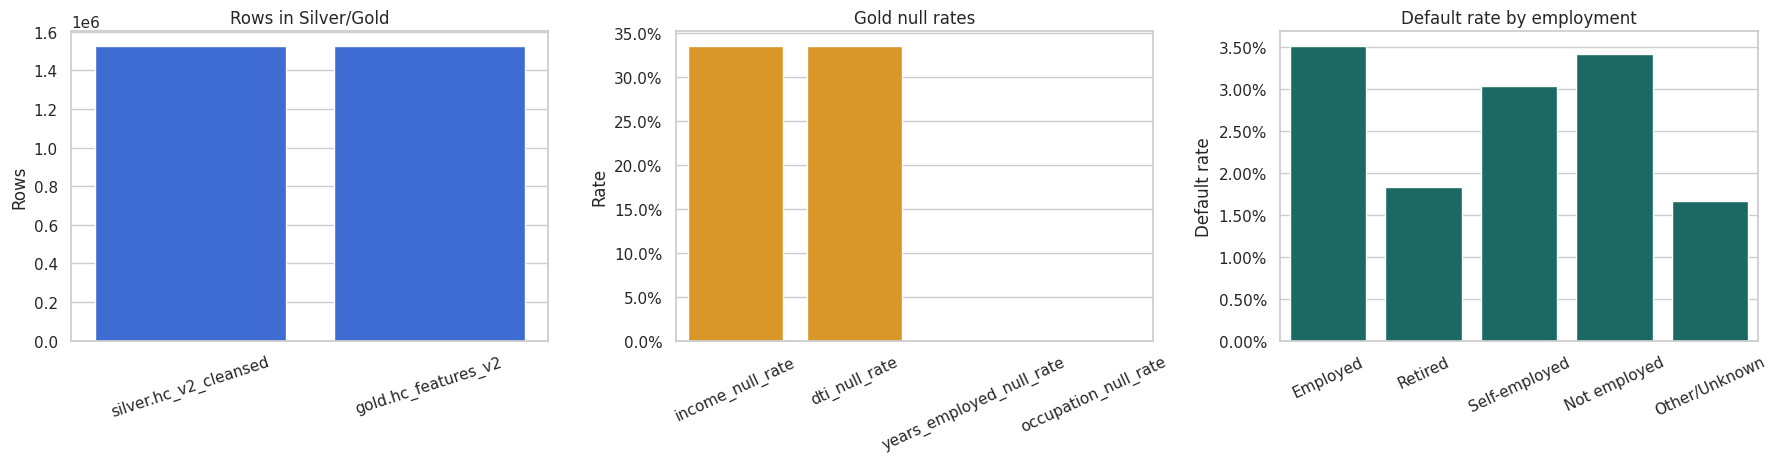

In [ ]:
from matplotlib.ticker import PercentFormatter

print("=" * 70)
print("DATA VALIDATION")
print("=" * 70)

inventory = con.execute("""
SELECT schema_name AS table_schema, table_name, estimated_size AS rows_estimate
FROM duckdb_tables()
WHERE (schema_name='bronze' AND table_name IN (
        'train_base', 'train_static_0', 'train_static_cb_0',
        'train_person_1', 'train_credit_bureau_a_1', 'train_applprev_1'
      ))
   OR (schema_name='silver' AND table_name='hc_v2_cleansed')
   OR (schema_name='gold' AND table_name='hc_features_v2')
ORDER BY schema_name, table_name
""").df()
display(inventory)

table_stats = []
for table_name in ["silver.hc_v2_cleansed", "gold.hc_features_v2"]:
    n_rows = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    default_rate = con.execute(
        f"SELECT AVG(CAST(is_default AS DOUBLE)) FROM {table_name}"
    ).fetchone()[0]
    table_stats.append({"table": table_name, "rows": n_rows, "default_rate": default_rate})
    print(f"{table_name:<24} rows={n_rows:,} | default_rate={default_rate:.2%}")
table_stats = pd.DataFrame(table_stats)

silver_cols = set(con.execute("""
SELECT column_name
FROM information_schema.columns
WHERE table_schema='silver' AND table_name='hc_v2_cleansed'
""").df()["column_name"])
missing_silver = sorted(REQUIRED_COLUMNS - silver_cols)
if missing_silver:
    raise RuntimeError("silver.hc_v2_cleansed thiếu cột: " + ", ".join(missing_silver))
print(f"Silver schema OK: {len(REQUIRED_COLUMNS)} required columns")

gold_cols = set(con.execute("""
SELECT column_name
FROM information_schema.columns
WHERE table_schema='gold' AND table_name='hc_features_v2'
""").df()["column_name"])
if REMOVED_FEATURES & gold_cols:
    print("Gold still contains legacy columns:", sorted(REMOVED_FEATURES & gold_cols))
else:
    print("Gold legacy self-reported/demographic columns removed OK")

quality = con.execute("""
SELECT
    COUNT(*) AS rows,
    AVG(CAST(is_default AS DOUBLE)) AS default_rate,
    AVG(CAST(stated_monthly_income IS NULL AS DOUBLE)) AS income_null_rate,
    AVG(CAST(debt_to_income_ratio IS NULL AS DOUBLE)) AS dti_null_rate,
    AVG(CAST(years_employed IS NULL AS DOUBLE)) AS years_employed_null_rate,
    AVG(CAST(occupation_type IS NULL AS DOUBLE)) AS occupation_null_rate,
    AVG(CAST(income_verifiable_flag AS DOUBLE)) AS income_verifiable_rate
FROM gold.hc_features_v2
""").df().T.rename(columns={0: "value"})
display(quality)

employment = con.execute("""
SELECT
    employment_status_grouped,
    COUNT(*) AS rows,
    AVG(CAST(is_default AS DOUBLE)) AS default_rate,
    AVG(years_employed) AS avg_years_employed,
    AVG(CAST(income_verifiable_flag AS DOUBLE)) AS income_verifiable_rate
FROM gold.hc_features_v2
GROUP BY 1
ORDER BY rows DESC
""").df()
display(employment)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

sns.barplot(data=table_stats, x="table", y="rows", ax=axes[0], color="#2563eb")
axes[0].set_title("Rows in Silver/Gold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=18)

null_rates = (
    quality.loc[[
        "income_null_rate", "dti_null_rate", "years_employed_null_rate",
        "occupation_null_rate",
    ]]
    .reset_index()
    .rename(columns={"index": "metric", "value": "rate"})
)
sns.barplot(data=null_rates, x="metric", y="rate", ax=axes[1], color="#f59e0b")
axes[1].set_title("Gold null rates")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rate")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(
    data=employment,
    x="employment_status_grouped",
    y="default_rate",
    ax=axes[2],
    color="#0f766e",
)
axes[2].set_title("Default rate by employment")
axes[2].set_xlabel("")
axes[2].set_ylabel("Default rate")
axes[2].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## 2. Model Contract Validation

Cell này so sánh `feature_cols` trong artifact với feature list từ training scripts. Nếu mismatch, notebook sẽ in diff để biết đang lệch ở đâu. Biểu đồ giúp nhìn nhanh số feature trong script/artifact và tỉ lệ numeric/categorical của từng model.


MODEL CONTRACT VALIDATION


,artifact,model_version,script_feature_count,artifact_feature_count,matches_training_script,thresholds
0,customer_risk_model.pkl,customer_lgbm_v4_stability,35,35,True,"{'low': 0.2, 'high': 0.4}"
1,scorecard_model.pkl,scorecard_v2,30,30,True,"{'low': 0.2, 'high': 0.4}"


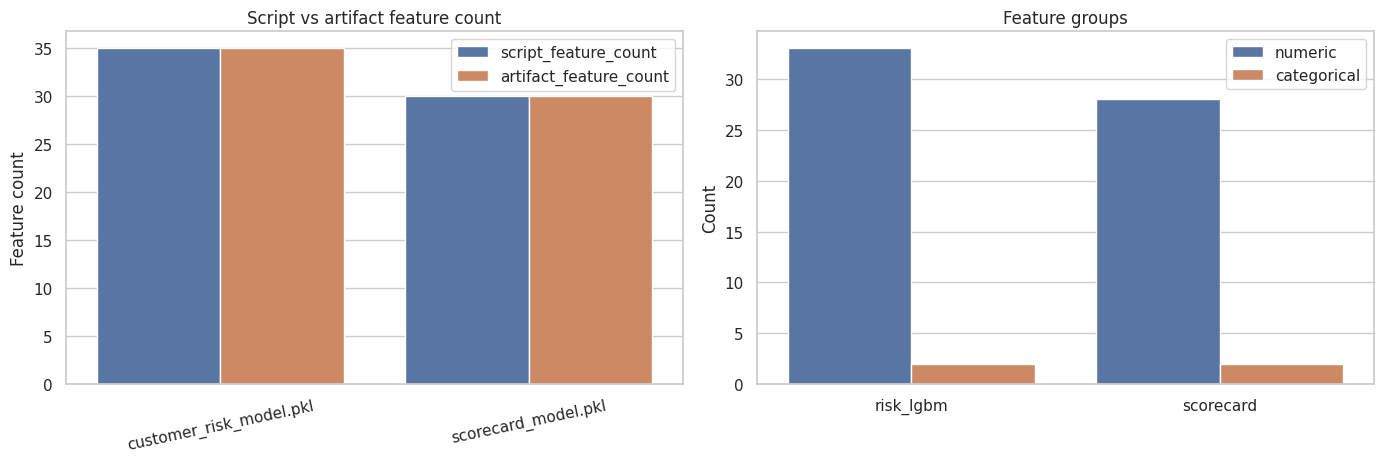

No legacy credit_score/rating/gender/children/family features in model contracts
Training queries OK against gold.hc_features_v2


In [4]:
def feature_diff(expected: list[str], actual: list[str]) -> pd.DataFrame:
    rows = []
    for feature in expected:
        if feature not in actual:
            rows.append({"type": "missing_in_artifact", "feature": feature})
    for feature in actual:
        if feature not in expected:
            rows.append({"type": "extra_in_artifact", "feature": feature})
    for idx, (exp, got) in enumerate(zip(expected, actual)):
        if exp != got:
            rows.append({"type": "first_order_diff", "feature": f"index={idx}: expected={exp}, artifact={got}"})
            break
    return pd.DataFrame(rows)

print("=" * 70)
print("MODEL CONTRACT VALIDATION")
print("=" * 70)

risk_artifact = joblib.load(RISK_MODEL_PATH)
scorecard_artifact = joblib.load(SCORECARD_MODEL_PATH)

checks = pd.DataFrame([
    {
        "artifact": RISK_MODEL_PATH.name,
        "model_version": risk_artifact.get("model_version"),
        "script_feature_count": len(LGBM_FEATURES),
        "artifact_feature_count": len(risk_artifact.get("feature_cols", [])),
        "matches_training_script": risk_artifact.get("feature_cols") == LGBM_FEATURES,
        "thresholds": risk_artifact.get("thresholds"),
    },
    {
        "artifact": SCORECARD_MODEL_PATH.name,
        "model_version": "scorecard_v2",
        "script_feature_count": len(SCORECARD_FEATURES),
        "artifact_feature_count": len(scorecard_artifact.get("feature_cols", [])),
        "matches_training_script": scorecard_artifact.get("feature_cols") == SCORECARD_FEATURES,
        "thresholds": scorecard_artifact.get("thresholds"),
    },
])
display(checks)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
count_plot = checks.melt(
    id_vars=["artifact", "matches_training_script"],
    value_vars=["script_feature_count", "artifact_feature_count"],
    var_name="source",
    value_name="feature_count",
)
sns.barplot(data=count_plot, x="artifact", y="feature_count", hue="source", ax=axes[0])
axes[0].set_title("Script vs artifact feature count")
axes[0].set_xlabel("")
axes[0].set_ylabel("Feature count")
axes[0].tick_params(axis="x", rotation=12)
axes[0].legend(title="")

feature_groups = pd.DataFrame([
    {"model": "risk_lgbm", "role": "numeric", "count": len(LGBM_NUMERIC_FEATURES)},
    {"model": "risk_lgbm", "role": "categorical", "count": len(LGBM_CATEGORICAL_FEATURES)},
    {"model": "scorecard", "role": "numeric", "count": len(SCORECARD_NUMERIC_FEATURES)},
    {"model": "scorecard", "role": "categorical", "count": len(SCORECARD_CATEGORICAL_FEATURES)},
])
sns.barplot(data=feature_groups, x="model", y="count", hue="role", ax=axes[1])
axes[1].set_title("Feature groups")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].legend(title="")

plt.tight_layout()
plt.show()

if not checks["matches_training_script"].all():
    print("Risk feature diff:")
    display(feature_diff(LGBM_FEATURES, risk_artifact.get("feature_cols", [])))
    print("Scorecard feature diff:")
    display(feature_diff(SCORECARD_FEATURES, scorecard_artifact.get("feature_cols", [])))
    raise RuntimeError(
        "Artifact feature_cols không khớp training script. "
        "Restart kernel + Run All; nếu vẫn lỗi thì retrain artifact."
    )

for model_name, features in {
    "risk_lgbm": LGBM_FEATURES,
    "scorecard": SCORECARD_FEATURES,
}.items():
    overlap = sorted(set(features) & REMOVED_FEATURES)
    if overlap:
        raise RuntimeError(f"{model_name} còn feature legacy: {overlap}")
print("No legacy credit_score/rating/gender/children/family features in model contracts")

con.execute(LGBM_QUERY + " LIMIT 5").df()
con.execute(SCORECARD_QUERY + " LIMIT 5").df()
print("Training queries OK against gold.hc_features_v2")

## 3. Model Evaluation

Cell này mirror cleanup trong training scripts rồi đánh giá lại artifacts trên split 80/20 cố định. Ngoài bảng metrics/report, cell có biểu đồ metric summary và threshold tradeoff để nhìn nhanh rủi ro khi đổi ngưỡng auto-reject.


MODEL EVALUATION


,model,rows,features,roc_auc,avg_precision,default_rate_test
0,customer_lgbm_v4_stability,1526659,35,0.8065,0.1330,0.0314
1,scorecard_v2,1015397,30,0.7367,0.0889,0.0321



LightGBM classification report
              precision    recall  f1-score   support

  No Default       0.99      0.74      0.84    295733
     Default       0.08      0.73      0.15      9599

    accuracy                           0.74    305332
   macro avg       0.54      0.73      0.50    305332
weighted avg       0.96      0.74      0.82    305332


Scorecard classification report @ 0.50
              precision    recall  f1-score   support

  No Default       0.97      1.00      0.98    196569
     Default       0.09      0.00      0.00      6511

    accuracy                           0.97    203080
   macro avg       0.53      0.50      0.49    203080
weighted avg       0.94      0.97      0.95    203080



,threshold,rejected,rejected_rate,recall_default,precision_default
0,0.1500,219386,0.7185,0.9716,0.0425
1,0.2000,194363,0.6366,0.9497,0.0469
2,0.2500,172348,0.5645,0.9265,0.0516
3,0.3000,152137,0.4983,0.8971,0.0566
4,0.3500,133652,0.4377,0.8628,0.0620
5,0.4000,116296,0.3809,0.8210,0.0678


Scorecard range: 300-850 | mean=594 | median=596


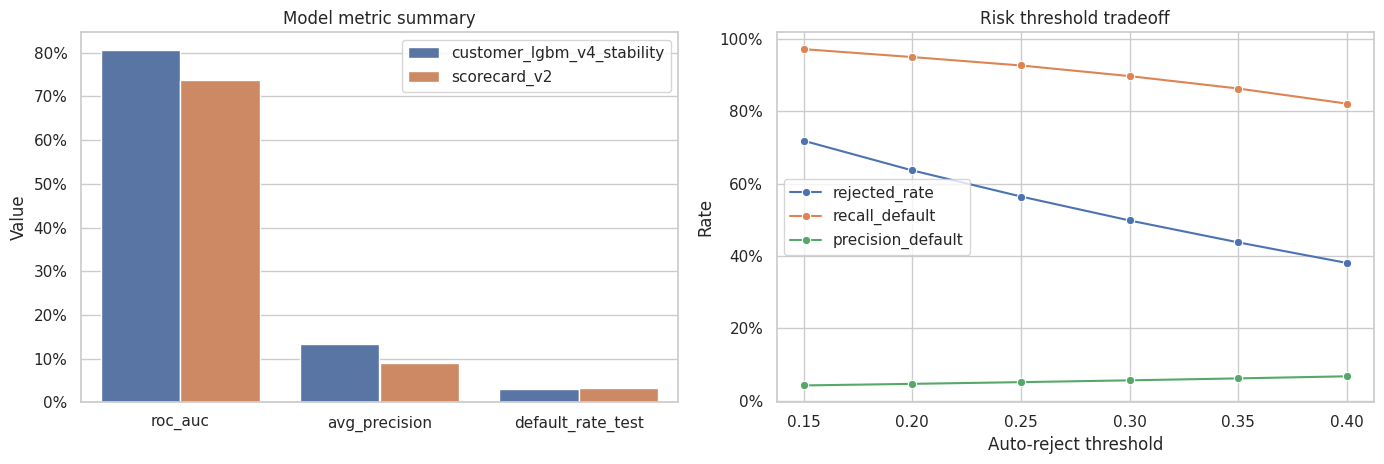

In [5]:
from matplotlib.ticker import PercentFormatter

print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

# LightGBM risk model: mirror training cleanup, no credit_score dependency.
df_l = con.execute(LGBM_QUERY).df().dropna(subset=["is_default"])
df_l["employment_status"] = df_l["employment_status"].fillna("Other/Unknown")
df_l["occupation_type"] = df_l["occupation_type"].fillna("OTHER")
df_l[LGBM_NUMERIC_FEATURES] = df_l[LGBM_NUMERIC_FEATURES].astype("float64")

_, X_l_test, _, y_l_test = train_test_split(
    df_l[LGBM_FEATURES],
    df_l["is_default"],
    test_size=0.2,
    random_state=42,
    stratify=df_l["is_default"],
)
y_l_prob = risk_artifact["pipeline"].predict_proba(X_l_test)[:, 1]
y_l_pred = risk_artifact["pipeline"].predict(X_l_test)

# LR scorecard: mirror training cleanup.
df_s = con.execute(SCORECARD_QUERY).df().dropna(subset=["is_default"])
df_s[SCORECARD_NUMERIC_FEATURES] = df_s[SCORECARD_NUMERIC_FEATURES].fillna(
    df_s[SCORECARD_NUMERIC_FEATURES].median()
)
df_s[SCORECARD_CATEGORICAL_FEATURES] = df_s[SCORECARD_CATEGORICAL_FEATURES].fillna("Other/Unknown")

_, X_s_test, _, y_s_test = train_test_split(
    df_s[SCORECARD_FEATURES],
    df_s["is_default"],
    test_size=0.2,
    random_state=42,
    stratify=df_s["is_default"],
)
y_s_prob = scorecard_artifact["pipeline"].predict_proba(X_s_test)[:, 1]
y_s_pred = (y_s_prob >= 0.5).astype(int)
scores = prob_to_score(y_s_prob)

metrics = pd.DataFrame([
    {
        "model": "customer_lgbm_v4_stability",
        "rows": len(df_l),
        "features": len(LGBM_FEATURES),
        "roc_auc": roc_auc_score(y_l_test, y_l_prob),
        "avg_precision": average_precision_score(y_l_test, y_l_prob),
        "default_rate_test": float(np.mean(y_l_test)),
    },
    {
        "model": "scorecard_v2",
        "rows": len(df_s),
        "features": len(SCORECARD_FEATURES),
        "roc_auc": roc_auc_score(y_s_test, y_s_prob),
        "avg_precision": average_precision_score(y_s_test, y_s_prob),
        "default_rate_test": float(np.mean(y_s_test)),
    },
])
display(metrics)

print("\nLightGBM classification report")
print(classification_report(y_l_test, y_l_pred, target_names=["No Default", "Default"]))

print("\nScorecard classification report @ 0.50")
print(classification_report(y_s_test, y_s_pred, target_names=["No Default", "Default"]))

threshold_rows = []
for threshold in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
    mask = y_l_prob >= threshold
    threshold_rows.append({
        "threshold": threshold,
        "rejected": int(mask.sum()),
        "rejected_rate": float(mask.mean()),
        "recall_default": float(y_l_test[mask].sum()) / max(float(y_l_test.sum()), 1.0),
        "precision_default": float(y_l_test[mask].mean()) if mask.sum() else 0.0,
    })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

print(
    f"Scorecard range: {int(scores.min())}-{int(scores.max())} | "
    f"mean={scores.mean():.0f} | median={int(np.median(scores))}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
metric_plot = metrics.melt(
    id_vars=["model"],
    value_vars=["roc_auc", "avg_precision", "default_rate_test"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=metric_plot, x="metric", y="value", hue="model", ax=axes[0])
axes[0].set_title("Model metric summary")
axes[0].set_xlabel("")
axes[0].set_ylabel("Value")
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(title="", loc="upper right")

threshold_long = threshold_table.melt(
    id_vars=["threshold"],
    value_vars=["rejected_rate", "recall_default", "precision_default"],
    var_name="metric",
    value_name="value",
)
sns.lineplot(data=threshold_long, x="threshold", y="value", hue="metric", marker="o", ax=axes[1])
axes[1].set_title("Risk threshold tradeoff")
axes[1].set_xlabel("Auto-reject threshold")
axes[1].set_ylabel("Rate")
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(title="")

plt.tight_layout()
plt.show()

## 4. Evaluation Dashboard

Dashboard này gom các biểu đồ đánh giá chính: ROC/PR, phân phối xác suất, phân phối score, confusion matrix và feature importance. Đây là phần trực quan nhất để trình bày kết quả model.


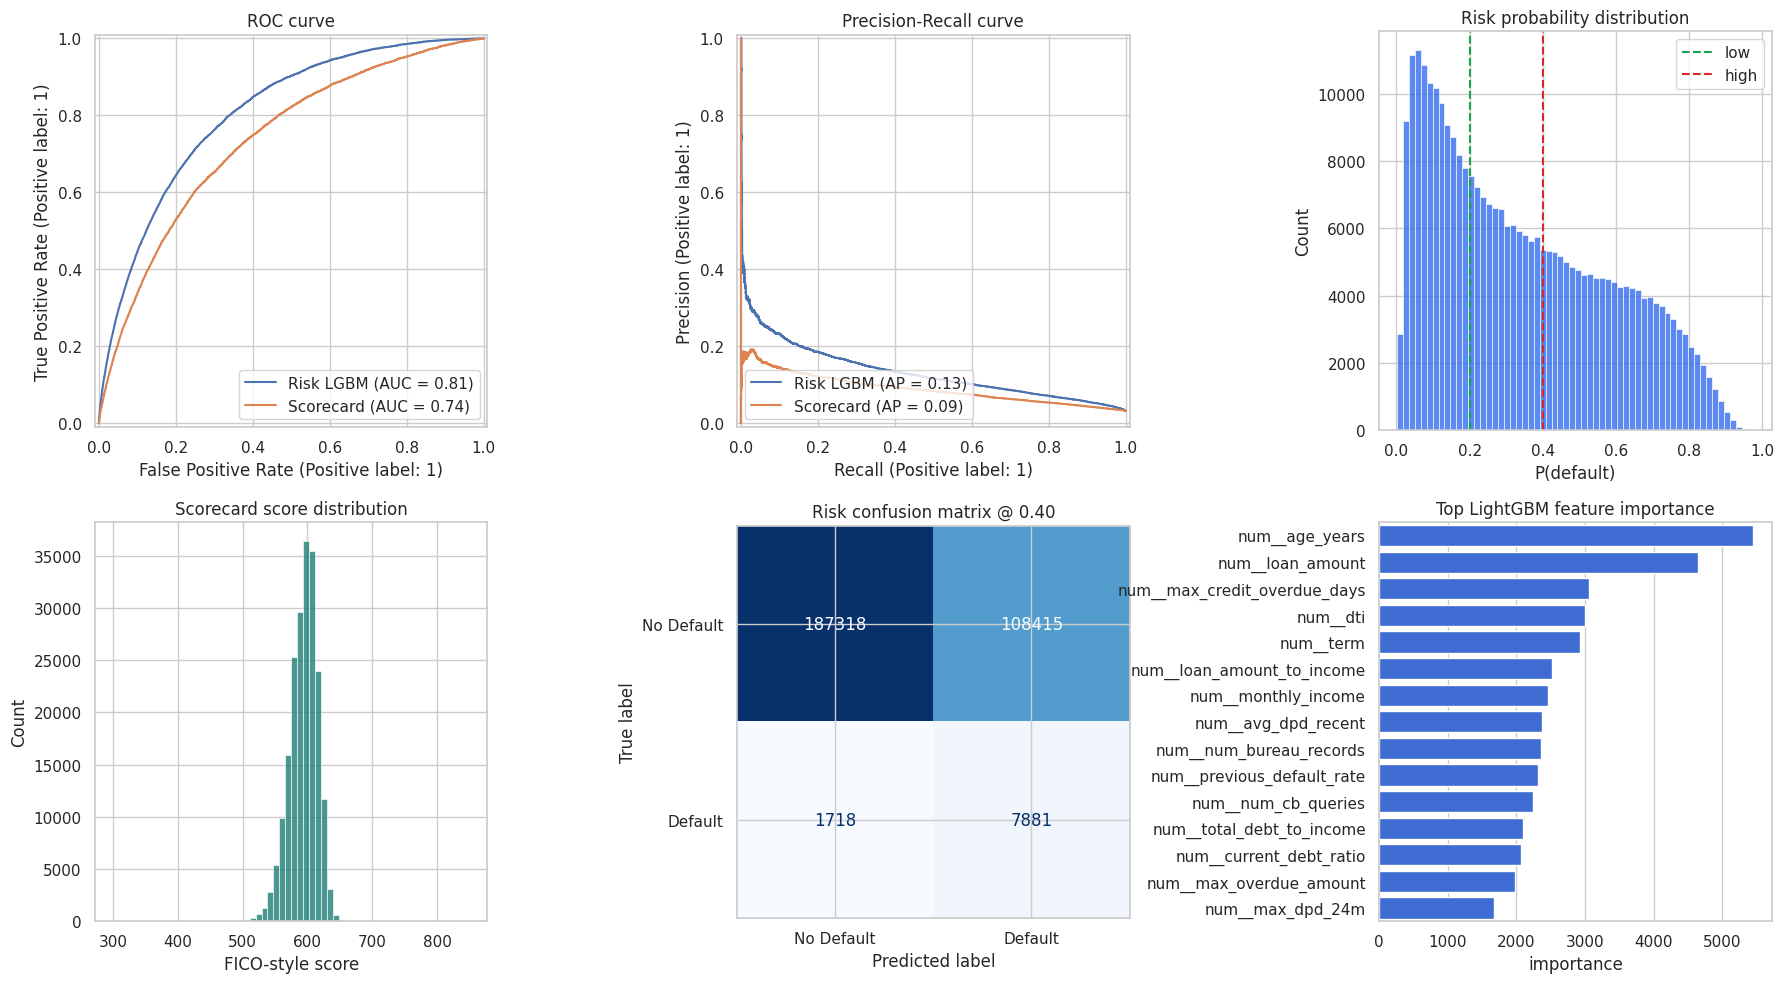

,feature,importance
25,num__age_years,5443
1,num__loan_amount,4650
17,num__max_credit_overdue_days,3051
3,num__dti,3004
2,num__term,2933
4,num__loan_amount_to_income,2523
0,num__monthly_income,2459
11,num__avg_dpd_recent,2379
14,num__num_bureau_records,2361
22,num__previous_default_rate,2310


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

RocCurveDisplay.from_predictions(y_l_test, y_l_prob, name="Risk LGBM", ax=axes[0, 0])
RocCurveDisplay.from_predictions(y_s_test, y_s_prob, name="Scorecard", ax=axes[0, 0])
axes[0, 0].set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(y_l_test, y_l_prob, name="Risk LGBM", ax=axes[0, 1])
PrecisionRecallDisplay.from_predictions(y_s_test, y_s_prob, name="Scorecard", ax=axes[0, 1])
axes[0, 1].set_title("Precision-Recall curve")

sns.histplot(y_l_prob, bins=60, ax=axes[0, 2], color="#2563eb")
axes[0, 2].axvline(risk_artifact["thresholds"]["low"], color="#16a34a", linestyle="--", label="low")
axes[0, 2].axvline(risk_artifact["thresholds"]["high"], color="#dc2626", linestyle="--", label="high")
axes[0, 2].set_title("Risk probability distribution")
axes[0, 2].set_xlabel("P(default)")
axes[0, 2].legend()

sns.histplot(scores, bins=60, ax=axes[1, 0], color="#0f766e")
axes[1, 0].set_title("Scorecard score distribution")
axes[1, 0].set_xlabel("FICO-style score")

risk_high = risk_artifact["thresholds"]["high"]
y_l_high_pred = (y_l_prob >= risk_high).astype(int)
ConfusionMatrixDisplay(
    confusion_matrix(y_l_test, y_l_high_pred),
    display_labels=["No Default", "Default"],
).plot(ax=axes[1, 1], cmap="Blues", colorbar=False)
axes[1, 1].set_title(f"Risk confusion matrix @ {risk_high:.2f}")

classifier = risk_artifact["pipeline"].named_steps["classifier"]
preprocessor = risk_artifact["pipeline"].named_steps["preprocessor"]
importance = pd.DataFrame({
    "feature": preprocessor.get_feature_names_out(),
    "importance": classifier.feature_importances_,
}).sort_values("importance", ascending=False)
sns.barplot(data=importance.head(15), x="importance", y="feature", ax=axes[1, 2], color="#2563eb")
axes[1, 2].set_title("Top LightGBM feature importance")
axes[1, 2].set_ylabel("")

plt.tight_layout()
plt.show()

display(importance.head(20))